# Maximum-likelihood estimate for mean lifetime in radioactive decay

Solve the tasks below.
For each task, give reasons for your solution by commenting in the notebook.
In conclusion, summarize your findings and contextualize them. What have you learned? Do the results make sense?

Your results will be examined for plagiarism. Please use your own plot styles, articulate your own thoughts, and present your own experimental approaches.

## Tasks

a) The maximum likelihood estimator for the mean lifetime $\tau$ of a radioactive decay described by the distribution

$$ f(t, \tau) = \frac{1}{\tau} e^{-t/\tau}$$

is given by 

$$\hat \tau = \frac{1}{n} \sum_{i=1}^n t_i.$$

The standard deviation of $\hat \tau$ can be estimated as 

$$\sigma_\tau^2 = - \left(\frac{\partial^2 \ln L(\tau)}{\partial^2 \tau} \Big|_{\tau = \hat \tau} \right)^{-1}$$

Use that to show that the uncertainty of $\hat \tau$ is given by $\sigma_\tau = \frac{\hat \tau}{\sqrt{n}}$.

b) Use the function *generate_data* defined below to generate a data set with $30$ and $300$ samples for $\tau = 2$, respectively. Plot the log-likelihood function $\ln L(\tau)$ along with the parabolic approximation. 

$$ \ln L(\tau) \approx \ln L_\mathrm{max} - \frac{(\tau - \hat \tau)^2}{2 \sigma_\tau^2}$$

What can you conclude about the validity of the approximation as the sample size increases?

c) Generate 1000 data sets each with 500 samples for $\tau = 2$ and determine for each data set whether the true value of tau lies in the interval $[\hat \tau - \sigma_{\hat \tau}, \hat \tau + \sigma_{\hat \tau}]$. How often does the true value lie in this interval? What is your expectation for the corresponding probability?


### Hints

It is recommended to not start coding right away. Try to really understand how the Likelihood looks first. Realize, what the Likelihood is a function of and what it describes.


### Uncertainty of a Parameter for Maximum Likelihood Estimator
a.) Use the given information to show that the uncertainty of $\hat \tau$ is given by $\sigma_\tau = \frac{\hat \tau}{\sqrt{n}}$.

We start with the general log-likelihood function. Inserting the decay distribution function $f(t ; \tau)$ and simplifying gives us a different expression for the log-likelihood.

\begin{align*}
    \ln L(\vec{t} ; \tau) &= \sum \limits_{i = 1}^{n} \ln f(t_i ; \tau) \\
    &= \sum \limits_{i = 1}^{n} \ln \Big( \frac{1}{\tau} e^{\frac{-t_i}{\tau}} \Big) \\
    &= \sum \limits_{i = 1}^{n} \Big( - \ln (\tau) - \frac{t_i}{\tau} \Big) \\
    &= - n \ln (\tau) - \frac{1}{\tau} \sum \limits_{i = 1}^{n} t_i \\
\end{align*}

It is much easier to take the derivative in this form. We compute the second derivative and then insert into the given/known equation for $\sigma_\tau^2$.

$$ \frac{\partial}{\partial \tau} \ln L(\vec{t} ; \tau) = -\frac{n}{\tau} + \frac{1}{\tau^2} \sum \limits_{i = 1}^{n} t_i $$

\begin{align*}
    \frac{\partial^2}{\partial \tau^2} \ln L(\vec{t} ; \tau) &= \frac{n}{\tau^2} - \frac{2}{\tau^3} \sum \limits_{i = 1}^{n} t_i \\
    &= \frac{n}{\tau^2} - \frac{2 n}{\tau^3} \cdot \frac{1}{n} \sum \limits_{i = 1}^{n} t_i \\
    &= \frac{n}{\tau^2} - \frac{2 n \hat{\tau}}{\tau^3}
\end{align*}

Lastly we can evaluate the second derivative at $\tau = \hat{\tau}$ and use it in the known equation for $\sigma_\tau^2$.

\begin{align*}
    \sigma_\tau^2 &= - \left(\frac{\partial^2 \ln L(\tau)}{\partial^2 \tau} \Big|_{\tau = \hat \tau} \right)^{-1} \\
    &= - \left( \frac{n}{\hat{\tau}^2} - \frac{2 n \hat{\tau}}{\hat{\tau}^3} \right)^{-1} \\
    &= - \left(- \frac{n}{\hat{\tau}^2} \right)^{-1} \\
    \sigma_\tau^2 &= \frac{\hat{\tau}^2}{n} \\
    \sigma_\tau &= \frac{\hat{\tau}}{\sqrt{n}}
\end{align*}

### Generating Data and Plotting log-likelihood Function
b) Use the function `generate_data` defined below to generate a data set with $30$ and $300$ samples for $\tau = 2$, respectively. Plot the log-likelihood function $\ln L(\tau)$ along with the parabolic approximation. What can you conclude about the validity of the approximation as the sample size increases?

As $n$ increases, we see below that the log-likelihood (as well as its approximation) gets much more strongly peaked (note the changing $y$-axis scales). The maximum likelihood is correctly predicted by both calculations. Increasing the sample size means the approximation becomes better near the maximum. However, the log-likelihood function clearly does not globally approach a quadratic, as we can see that the two sides stay very asymmetric, even at large sample sizes.

Therefore, the parabolic approximation is valid within a region around the maximum likelihood, even though the function is more complicated than this on a global view. This was expected due to the parabola being calculated from the Taylor expansion of $\ln L(\tau)$ around the maximum (to the second order).

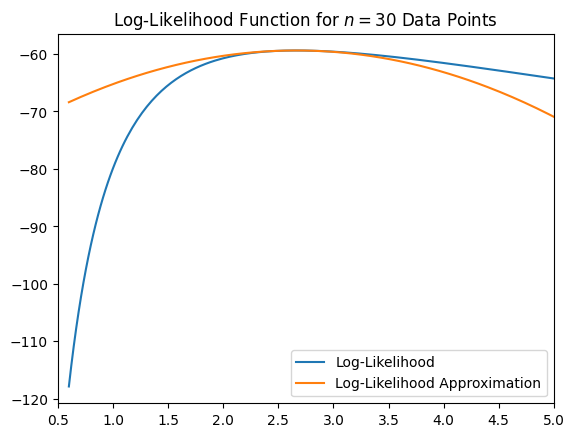

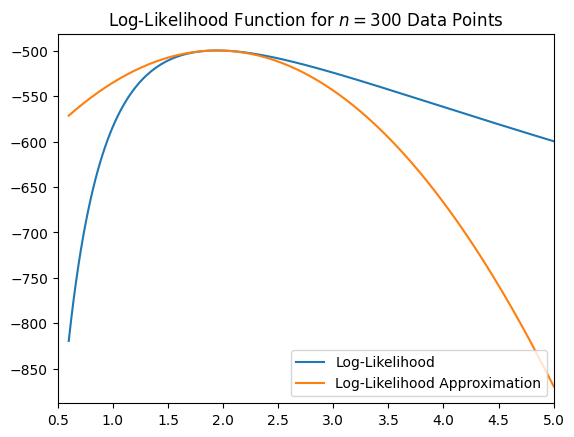

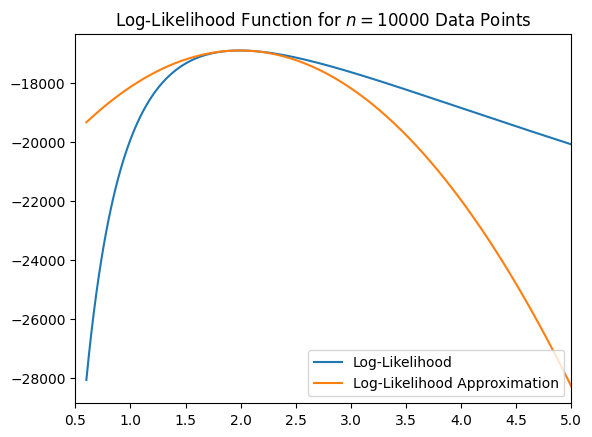

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_data(tau, n_samples):
    return np.random.exponential(tau, n_samples)

true_tau = 2

# define the decay function f(t ; tau), with error catching
def exp_decay(t, tau):
    if np.any(t < 0):
        raise ValueError(f'An element in t is negative!')
    if np.any(tau == 0):
        raise ValueError(f'An element in tau is zero! Cannot divide by zero!')
    return 1/tau * np.exp(-t / tau)

# gives tau_hat, the most likely value of the parameter, given the data
def max_llh_estimator(data):
    return np.mean(data)

# gives the uncertainty of tau_hat (see part a.))
def sigma_llh_estimator(data):
    return max_llh_estimator(data) / np.sqrt(len(data))

# likelihood is product of likelihoods of each value in data
def likelihood(tau, data):
    tau = np.atleast_1d(tau)
    data = np.atleast_1d(data)
    return np.prod(exp_decay(data[:, None], tau[None, :]), axis = 0)

# log of likelihood function is sum of the log of the likelihoods of each value in data (vectorized function)
def log_likelihood(tau, data):
    tau = np.atleast_1d(tau)
    data = np.atleast_1d(data)
    return np.sum(np.log(exp_decay(data[:, None], tau[None, :])), axis = 0)

def log_likelihood_approx(tau, data):
    tau_hat = max_llh_estimator(data)
    sigma_tau = sigma_llh_estimator(data)
    log_L_max = log_likelihood(tau_hat, data)
    return log_L_max - ((tau - tau_hat)**2 / (2 * sigma_tau**2))

# plot the true log-likelihood as well as its approximation for n data points
def plot_lllh_and_approx(n: int, xlim: tuple):
    data = generate_data(true_tau, n)
    tau_grid = np.linspace(xlim[0] + 0.1, xlim[1], 200)
    plt.plot(tau_grid, log_likelihood(tau_grid, data), label='Log-Likelihood')
    plt.plot(tau_grid, log_likelihood_approx(tau_grid, data), label='Log-Likelihood Approximation')
    plt.xlim(xlim)
    plt.title(f'Log-Likelihood Function for $n = {n}$ Data Points')
    plt.legend(loc = 'lower right')
    plt.show()

plot_lllh_and_approx(30, (0.5, 5))
plot_lllh_and_approx(300, (0.5, 5))
plot_lllh_and_approx(10000, (0.5, 5))

### Testing for True Value in Generated Data

c) Generate 1000 data sets each with 500 samples for $\tau = 2$ and determine for each data set whether the true value of $\tau$ lies in the interval $[\hat \tau - \sigma_{\hat \tau}, \hat \tau + \sigma_{\hat \tau}]$. How often does the true value lie in this interval? What is your expectation for the corresponding probability?


In this case we call a prediction successful if the true value of $\tau$ is within a $1\sigma$ interval of our (MLE) prediction $\hat{\tau}$.
By generating many data sets with large numbers of samples, we approximate the long-term expected number of successful predictions of $\tau$. Following the frequentist interpretation of probability, the long-term ratio of successes to failures is by definition the probability of success. In the work below, we calculate this ratio and report it as well.

For $1000$ data sets of $500$ samples, we get about $670$ successful predictions, meaning a success rate of $67 \%$. This success rate is our estimate/expectation for the probability of a successful prediction of $\tau$ when using the MLE method.

In [2]:
# generate interval using estimator of tau and its uncertainty
def find_interval(data) -> list:
    tau_hat = max_llh_estimator(data)
    sigma_tau = sigma_llh_estimator(data)
    return [tau_hat - sigma_tau, tau_hat + sigma_tau]

# check if a value is within an interval
def within_interval(x, interval) -> bool:
    return interval[0] <= x <= interval[1]

true_tau = 2

# generate a data sample and check if the true value was found within 1-sigma
def estimator_interval_test(true_tau, n_samples) -> bool:
    data = generate_data(true_tau, n_samples)
    interval = find_interval(data)
    return within_interval(true_tau, interval)

n_data_sets = 1000
n_samples = 500

# run the previous function many times and put return bools into a list, then count up successes
in_interval_list = [estimator_interval_test(true_tau, n_samples) for _ in range(n_data_sets)]
successes = in_interval_list.count(True)
frac_successes = successes / n_data_sets
print(f'{successes = }')
print(f'{frac_successes = }')

successes = 669
frac_successes = 0.669
